# Notebook 07 — Custom Networks & Model Persistence

This notebook covers two advanced topics:

1. **Custom `nn.Module` architectures** — when to replace the default MLP
   and how to pass your own network to any model class.
2. **Save/load and multi-stage training** — checkpointing, resuming, and
   a production-ready end-to-end workflow template.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
import pyUDE as ude

np.random.seed(5)
torch.manual_seed(5)

## 1 — Generate Data: Van der Pol Oscillator

The Van der Pol oscillator has stiff nonlinear dynamics:
```
dx/dt = y
dy/dt = μ(1 - x²)y - x
```
with `μ = 2.0`. The limit cycle and varying time scales make this a challenging
system for a small default MLP.

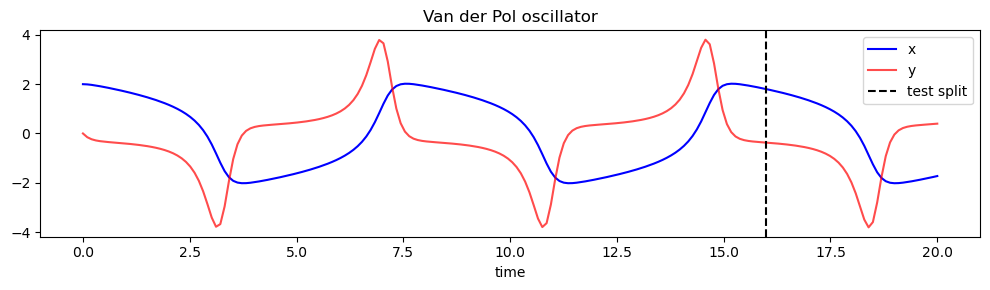

In [2]:
mu = 2.0

def van_der_pol(t, u):
    x, y = u
    return [y, mu*(1 - x**2)*y - x]

sol = solve_ivp(van_der_pol, [0, 20], [2.0, 0.0],
                t_eval=np.linspace(0, 20, 200),
                method='Radau')  # stiff solver

data = pd.DataFrame({'time': sol.t, 'x': sol.y[0], 'y': sol.y[1]})
train_data, test_data = ude.train_test_split(data, test_fraction=0.2)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(data['time'], data['x'], 'b-', lw=1.5, label='x')
ax.plot(data['time'], data['y'], 'r-', lw=1.5, label='y', alpha=0.7)
ax.axvline(train_data['time'].iloc[-1], color='k', ls='--', label='test split')
ax.legend(); ax.set_xlabel('time'); ax.set_title('Van der Pol oscillator')
plt.tight_layout(); plt.show()

## 2 — Default MLP Baseline

In [3]:
model_default = ude.NODE(train_data, hidden_units=64, hidden_layers=2)
model_default.train(loss='derivative_matching', epochs=150, verbose=False)

fc_default = model_default.forecast(steps=len(test_data))
min_len = min(len(fc_default), len(test_data))
state_cols = ['x', 'y']
rmse_default = ude.rmse(
    test_data[state_cols].iloc[:min_len].reset_index(drop=True),
    fc_default[state_cols].iloc[:min_len].reset_index(drop=True)
)['mean']
print(f'Default MLP test RMSE: {rmse_default:.4f}')

Default MLP test RMSE: 0.9200


## 3 — Residual Network

A residual (skip) connection adds the input back to the output:
`output = f(u) + u`. This helps when dynamics are near-identity — small corrections
to the current state — because the network only needs to learn the deviation.

In [4]:
class ResidualMLP(nn.Module):
    def __init__(self, dim: int, hidden: int = 64):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, dim)

    def forward(self, u: torch.Tensor) -> torch.Tensor:
        h = torch.tanh(self.fc1(u))
        h = torch.tanh(self.fc2(h))
        return self.fc3(h) + u   # skip connection

# Pass via network= parameter — set dtype to float64 to match training data
model_res = ude.NODE(train_data, network=ResidualMLP(2, hidden=64).double())
model_res.train(loss='derivative_matching', epochs=150, verbose=False)

fc_res = model_res.forecast(steps=len(test_data))
rmse_res = ude.rmse(
    test_data[state_cols].iloc[:min_len].reset_index(drop=True),
    fc_res[state_cols].iloc[:min_len].reset_index(drop=True)
)['mean']
print(f'Residual MLP test RMSE: {rmse_res:.4f}')
print(f'Improvement: {(rmse_default - rmse_res) / rmse_default * 100:.1f}%')

Residual MLP test RMSE: 1.3428
Improvement: -46.0%


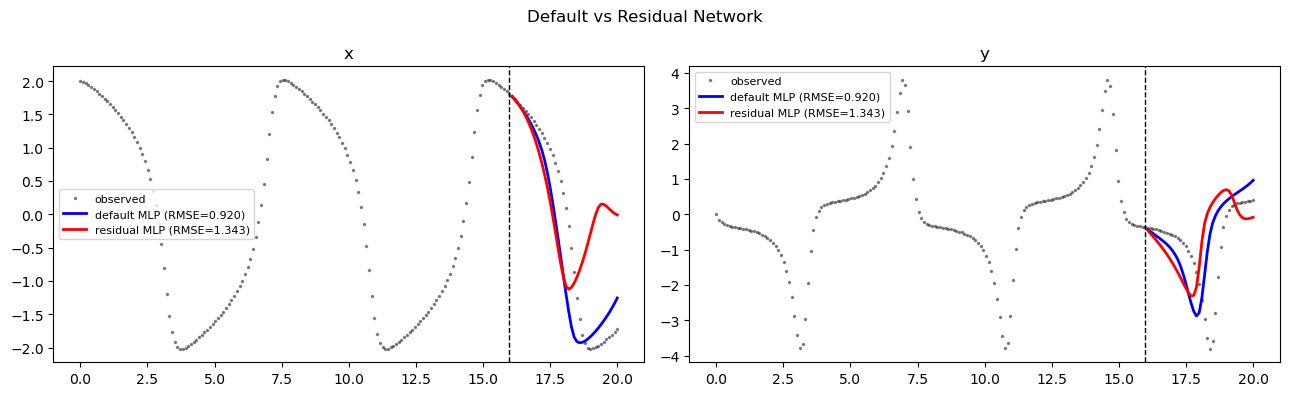

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, state_cols):
    ax.plot(data['time'], data[col], 'k.', ms=3, alpha=0.4, label='observed')
    ax.plot(fc_default['time'], fc_default[col], 'b-', lw=2,
            label=f'default MLP (RMSE={rmse_default:.3f})')
    ax.plot(fc_res['time'], fc_res[col], 'r-', lw=2,
            label=f'residual MLP (RMSE={rmse_res:.3f})')
    ax.axvline(train_data['time'].iloc[-1], color='k', ls='--', lw=1)
    ax.set_title(col); ax.legend(fontsize=8)
plt.suptitle('Default vs Residual Network'); plt.tight_layout(); plt.show()

## 4 — When to Use Custom Networks

| Scenario | Architecture suggestion |
|----------|------------------------|
| Dynamics are near-identity | Residual / skip connections |
| Default MLP underfits | Increase `hidden_units` or `hidden_layers` first |
| Known conserved quantities | Structured network with conservation built in |
| Fast-slow dynamics | Larger network or implicit integration (Julia) |
| General unknown dynamics | Default MLP (2 layers, 32 units) is a good start |

> **Important:** any custom network must call `.double()` to match pyUDE's float64 tensors.

## 5 — `save()` and `load_weights()`

In [6]:
import tempfile, os

# Save to a temporary file
tmpfile = os.path.join(tempfile.gettempdir(), 'van_der_pol_residual.pt')
model_res.save(tmpfile)
print(f'Saved to: {tmpfile}')

# Re-instantiate with the same architecture and load weights
model_reloaded = ude.NODE(train_data, network=ResidualMLP(2, hidden=64).double())
model_reloaded.load_weights(tmpfile)
print('Loaded.  is_trained:', model_reloaded.is_trained)

# Verify forecasts are identical
fc_reloaded = model_reloaded.forecast(steps=len(test_data))
max_diff = (fc_res[state_cols].values - fc_reloaded[state_cols].values).max()
print(f'Max abs difference between saved and reloaded forecast: {max_diff:.2e}')

Saved to: C:\Users\rokko\AppData\Local\Temp\van_der_pol_residual.pt
Loaded.  is_trained: True
Max abs difference between saved and reloaded forecast: 0.00e+00


## 6 — Multi-Stage Training with `train_history_`

Each call to `train()` continues from the current weights. The `train_history_`
attribute accumulates across all calls, so you can plot the full training trajectory.

In [7]:
model_staged = ude.NODE(train_data, hidden_units=64, hidden_layers=3)

# Stage 1: fast warm-up with high learning rate
model_staged.train(loss='derivative_matching', epochs=100,
                   learning_rate=1e-3, verbose=False)
phase1_end = len(model_staged.train_history_['train_loss'])

# Stage 2: refine with lower learning rate
model_staged.train(loss='derivative_matching', epochs=100,
                   learning_rate=3e-4, verbose=False)
phase2_end = len(model_staged.train_history_['train_loss'])

# Stage 3: fine-tune with weight decay for regularization
model_staged.train(loss='derivative_matching', epochs=100,
                   learning_rate=1e-4, weight_decay=1e-4, verbose=False)

print(f'Total epochs: {len(model_staged.train_history_["train_loss"])}')

Total epochs: 300


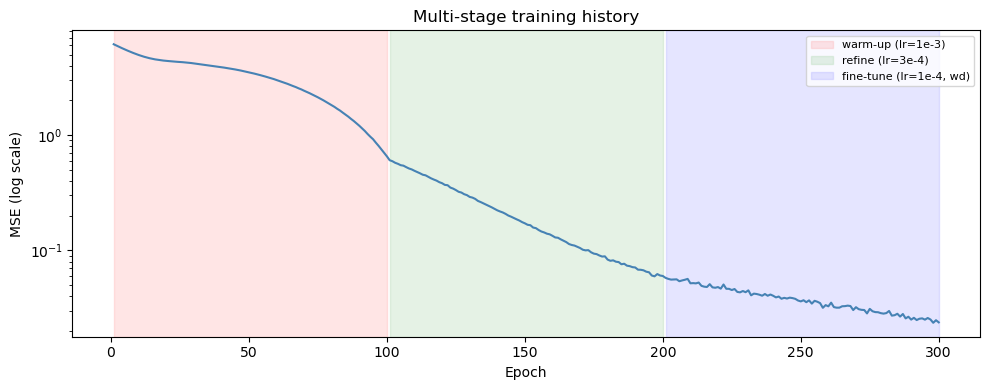

In [8]:
history = model_staged.train_history_['train_loss']
epochs  = range(1, len(history) + 1)
phases  = [(1, phase1_end, 'warm-up (lr=1e-3)'),
           (phase1_end+1, phase2_end, 'refine (lr=3e-4)'),
           (phase2_end+1, len(history), 'fine-tune (lr=1e-4, wd)')]

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(epochs, history, lw=1.5, color='steelblue')
colors = ['#ff9999', '#99cc99', '#9999ff']
for (start, end, label), c in zip(phases, colors):
    if end >= start:
        ax.axvspan(start, end, alpha=0.25, color=c, label=label)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log scale)')
ax.legend(fontsize=8); ax.set_title('Multi-stage training history')
plt.tight_layout(); plt.show()

## 7 — CustomDifferences Save/Load

In [9]:
def logistic_map(u, p, t):
    return torch.stack([p['r'] * u[0] * (1 - u[0] / 10.0)])

t_map = np.arange(50)
x_map = np.zeros(50); x_map[0] = 0.5
r_true = 0.9
for i in range(1, 50):
    x_map[i] = r_true * x_map[i-1] * (1 - x_map[i-1] / 10.0) + 0.01*np.random.randn()

map_data = pd.DataFrame({'time': t_map.astype(float), 'x': x_map})
cd_model = ude.CustomDifferences(map_data, logistic_map, init_params={'r': 0.5})
cd_model.train(epochs=200, verbose=False)
print('Learned r:', cd_model.get_params())

# Save and reload
cd_path = os.path.join(tempfile.gettempdir(), 'logistic_diff.pt')
cd_model.save(cd_path)
cd_reload = ude.CustomDifferences(map_data, logistic_map, init_params={'r': 0.5})
cd_reload.load_weights(cd_path)
print('Reloaded r:', cd_reload.get_params())

Learned r: {'r': 0.5252847420742603}
Reloaded r: {'r': 0.5252847420742603}


## 8 — Production Workflow Template

A clean end-to-end pattern you can copy-paste as a starting point for new projects.

In [10]:
import tempfile, os
import numpy as np, pandas as pd
import torch.nn as nn
import pyUDE as ude

# 1. Load or generate data
# data = pd.read_csv('my_data.csv')
# Using synthetic data for this demo:
t = np.linspace(0, 10, 100)
demo_data = pd.DataFrame({'time': t, 'x': np.sin(t), 'y': np.cos(t)})

# 2. Temporal split
train_df, test_df = ude.train_test_split(demo_data, test_fraction=0.2)

# 3. Build model (default MLP or custom network)
final = ude.NODE(train_df, hidden_units=32, hidden_layers=2)

# 4. Multi-stage training with validation tracking
final.train(loss='derivative_matching', epochs=100,
            val_data=test_df, val_interval=10,
            learning_rate=1e-3, verbose=False)

# 5. Evaluate on test set
fc = final.forecast(steps=len(test_df))
min_l = min(len(fc), len(test_df))
scores = ude.rmse(test_df[['x','y']].iloc[:min_l].reset_index(drop=True),
                  fc[['x','y']].iloc[:min_l].reset_index(drop=True))
print('Test RMSE:', scores)

# 6. Save checkpoint
ckpt = os.path.join(tempfile.gettempdir(), 'final_model.pt')
final.save(ckpt)
print(f'Model saved to {ckpt}')

# 7. Load and forecast in new session
loaded = ude.NODE(train_df, hidden_units=32, hidden_layers=2)
loaded.load_weights(ckpt)
future = loaded.forecast(steps=50)
print('Future forecast shape:', future.shape)

Test RMSE: {'x': 0.009308077175659275, 'y': 0.011662664919268723, 'mean': 0.010551257122427889}
Model saved to C:\Users\rokko\AppData\Local\Temp\final_model.pt
Future forecast shape: (50, 3)


## Key Takeaways

- Pass any `nn.Module` via `network=` to override the default MLP — always call
  `.double()` on your network to match pyUDE's float64 tensors.
- **Residual connections** help when dynamics are near-identity (small corrections).
- `save()` stores the network state dict and training metadata; `load_weights()` restores
  it — the **model architecture must match** at load time.
- `train_history_` accumulates across all `train()` calls — use it to plot the full
  multi-stage learning curve.
- `CustomDifferences` has its own checkpoint format (no `_ode_func`); use its
  own `save()` / `load_weights()` overrides.